In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from algoritmo_genetico import *

def graficos(valores_finais, num_execucoes, tamanho_populacao, todos_historicos, quantidade_itens, capacidade, itens, fator_penalidade, metrica):
    
    print(f"Executando o AG {num_execucoes} vezes. Isso pode levar alguns segundos...")
    # 1. Fase de Coleta de Dados
    for i in range(num_execucoes):
        melhor, pior, historico = algoritimo_genetico(200, tamanho_populacao, quantidade_itens, capacidade, itens, fator_penalidade)
        
        # Guardamos apenas o número do lucro final
        valores_finais.append(melhor[metrica])
        # Guardamos a linha do tempo dessa execução
        todos_historicos.append(historico)

    # 2. Fase de Cálculos Estatísticos
    media_fitness = np.mean(valores_finais)
    desvio_padrao = np.std(valores_finais)
    melhor_absoluto = np.max(valores_finais)

    print("\n--- RESULTADOS ESTATÍSTICOS (50 EXECUÇÕES) ---")
    print(f"Melhor Valor Absoluto Encontrado: {melhor_absoluto}")
    print(f"Média de Lucro Final: {media_fitness:.2f}")
    print(f"Desvio Padrão: {desvio_padrao:.2f}")

    # 3. Preparando os Gráficos
    # Criando uma "tela" com 3 espaços para gráficos (1 linha, 3 colunas)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfico A: Histograma de Distribuição
    ax1.hist(valores_finais, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.axvline(media_fitness, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media_fitness:.0f}')
    ax1.set_title("Distribuição dos Resultados Finais")
    ax1.set_xlabel("Lucro (Fitness)")
    ax1.set_ylabel("Frequência (Quantas vezes aconteceu)")
    ax1.legend()

    # Gráfico B: Boxplot para Desvio e Dispersão
    ax2.boxplot(valores_finais, vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen', color='green'))
    ax2.set_title("Variação e Dispersão (Boxplot)")
    ax2.set_xlabel("Lucro (Fitness)")
    ax2.set_yticks([]) # Remove eixo Y pois é apenas 1 item

    # Gráfico C: Curva de Convergência Média (com preenchimento dos históricos desiguais)
    tamanho_maximo = max(len(h) for h in todos_historicos)
    historicos_padronizados = []

    # Como o AG para em gerações diferentes, repetimos a nota final para empatar o tamanho das linhas
    for h in todos_historicos:
        ultimo_valor = h[-1]
        preenchimento = [ultimo_valor] * (tamanho_maximo - len(h))
        historicos_padronizados.append(h + preenchimento)

    # Calcula a média por geração
    media_por_geracao = np.mean(historicos_padronizados, axis=0)

    ax3.plot(media_por_geracao, color='purple', linewidth=2)
    ax3.set_title("Curva de Evolução Média")
    ax3.set_xlabel("Gerações")
    ax3.set_ylabel("Fitness Médio")
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Executando o AG 50 vezes. Isso pode levar alguns segundos...
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local
Encontrou otimo local

--- RESULTADOS ESTATÍSTICOS (50 EXECUÇÕES) ---
Melhor Valor Absoluto Encontrado: 14238
Média de Lucro 

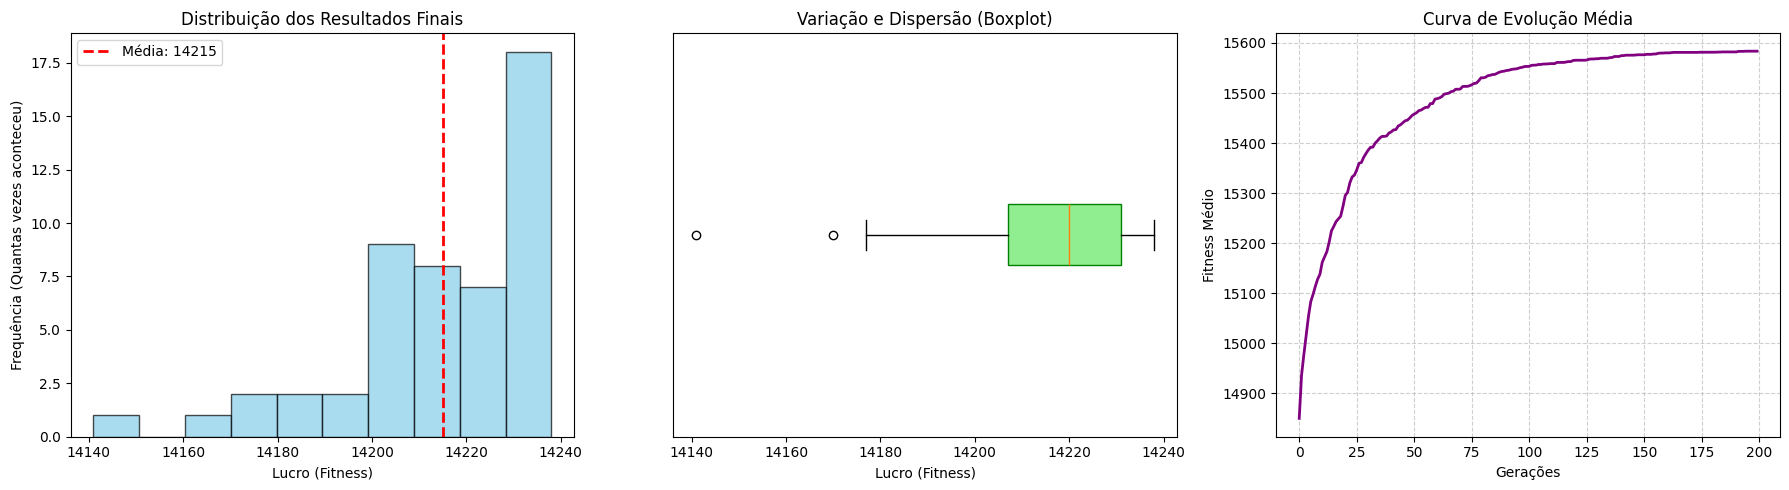

In [ ]:
quantidade_itens, capacidade, itens = carregar_dados_mochila("mochila.txt")

maior_razao = max(item['valor'] / item['peso'] for item in itens)
fator_penalidade = maior_razao + 1

# Listas para guardar os dados brutos das 50 execuções
valores_finais = []
todos_historicos = []

num_execucoes = 50
tamanho_populacao = 100
graficos(valores_finais, num_execucoes, tamanho_populacao, todos_historicos, quantidade_itens, capacidade, itens, fator_penalidade, 'fitness')